In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        patch_dim = patch_size * patch_size * in_channels  # 2*2*3 = 12
        self.projection = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size)  # (batch, 3, 16, 32, 2)
        x = x.unfold(3, self.patch_size, self.patch_size)  # (batch, 3, 16, 16, 2, 2)
        x = x.contiguous().view(batch_size, -1, self.patch_size * self.patch_size * 3)
        # Step 3: Project to embedding dimension
        x = self.projection(x)  # (batch, 256, 256)
        return x

In [3]:
patch_embed = PatchEmbedding()
dummy_img = torch.randn(2, 3, 32, 32)
output = patch_embed(dummy_img)
print(f"Output shape: {output.shape}")
print(f"Number of patches: {patch_embed.num_patches}")

Output shape: torch.Size([2, 256, 256])
Number of patches: 256


In [4]:
class PositionalEmbedding(nn.Module):
    def __init__(self, num_patches=256, embed_dim=256):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))

    def forward(self, x):
        return x + self.pos_embedding

In [5]:
pos_embed = PositionalEmbedding(num_patches=256, embed_dim=256)
dummy_patches = torch.randn(2, 256, 256)
output = pos_embed(dummy_patches)
print(f"Output shape: {output.shape}")
print(f"Are values different? {not torch.equal(dummy_patches, output)}")

Output shape: torch.Size([2, 256, 256])
Are values different? True


In [6]:
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

In [7]:
class MixerBlock(nn.Module):
    def __init__(self, num_patches=256, embed_dim=256, token_mix_hidden=128, channel_mix_hidden=512):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.token_mixing = MLP(num_patches, token_mix_hidden)
        self.channel_mixing = MLP(embed_dim, channel_mix_hidden)

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        x = x.transpose(1, 2)
        x = self.token_mixing(x)
        x = x.transpose(1, 2)
        x = x + residual
        residual = x
        x = self.norm2(x)
        x = self.channel_mixing(x)
        x = x + residual
        return x

In [8]:
mixer_block = MixerBlock(num_patches=256, embed_dim=256)
dummy_input = torch.randn(2, 256, 256)
output = mixer_block(dummy_input)
print(f"Output shape: {output.shape}")
print(f"Shape preserved: {output.shape == dummy_input.shape}")

Output shape: torch.Size([2, 256, 256])
Shape preserved: True


In [9]:
class MLPMixer(nn.Module):
    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 num_classes=10,
                 embed_dim=256,
                 num_blocks=8,
                 token_mix_hidden=256,
                 channel_mix_hidden=512):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.pos_embed = PositionalEmbedding(num_patches, embed_dim)
        self.mixer_blocks = nn.ModuleList([
            MixerBlock(num_patches, embed_dim, token_mix_hidden, channel_mix_hidden)
            for _ in range(num_blocks)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.pos_embed(x)
        for mixer_block in self.mixer_blocks:
            x = mixer_block(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.head(x)
        return x

In [10]:
model = MLPMixer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=256,
    num_blocks=8
)

dummy_batch = torch.randn(4, 3, 32, 32)
output = model(dummy_batch)
print(f"Output shape: {output.shape}")
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")

Output shape: torch.Size([4, 10])
Model has 2,408,202 parameters


In [11]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:06<00:00, 28.2MB/s]


Training samples: 50000
Test samples: 10000


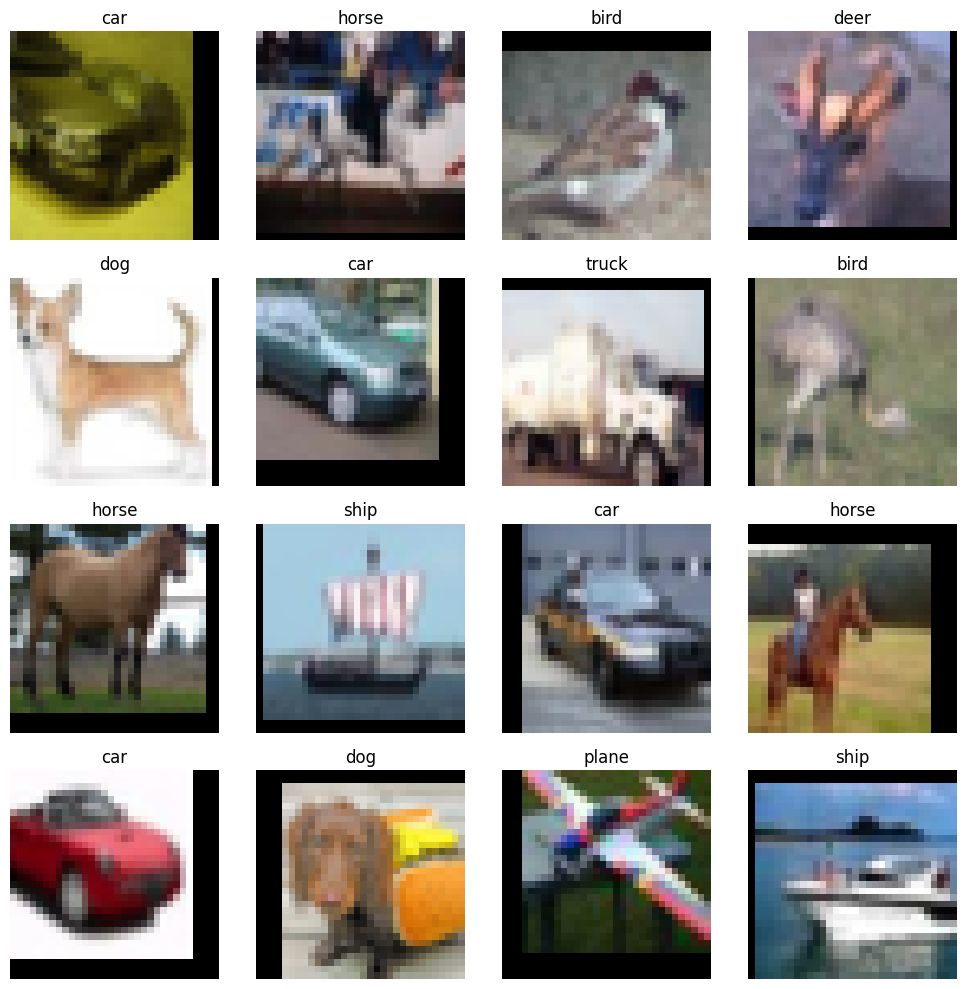

In [12]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def show_images(dataset, n=16):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        img = img * 0.5 + 0.5
        img = img.numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"{classes[label]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_images(train_dataset)

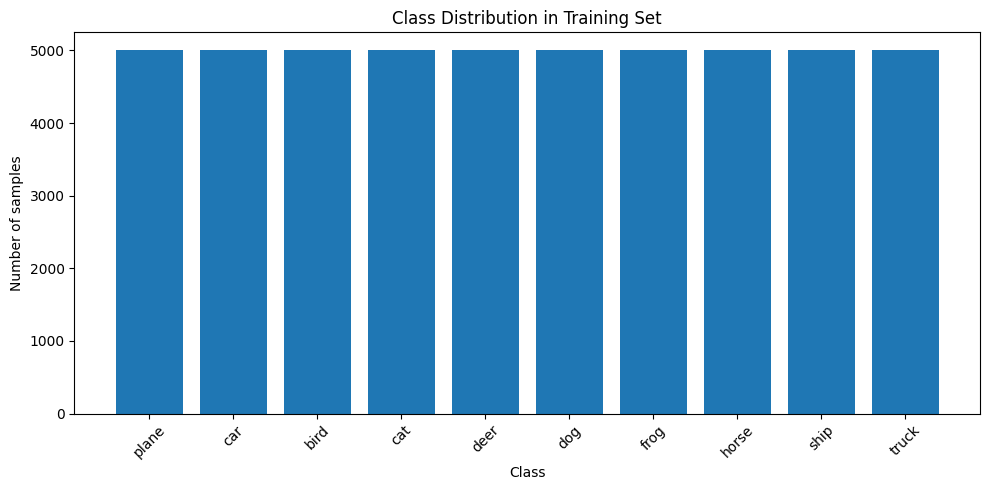


Class distribution:
plane: 5000 samples
car: 5000 samples
bird: 5000 samples
cat: 5000 samples
deer: 5000 samples
dog: 5000 samples
frog: 5000 samples
horse: 5000 samples
ship: 5000 samples
truck: 5000 samples


In [13]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)

plt.figure(figsize=(10, 5))
plt.bar(range(len(classes)), [label_counts[i] for i in range(len(classes))])
plt.xticks(range(len(classes)), classes, rotation=45)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution in Training Set')
plt.tight_layout()
plt.show()

print("\nClass distribution:")
for i, class_name in enumerate(classes):
    print(f"{class_name}: {label_counts[i]} samples")

In [14]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nBatch statistics:")
print(f"Batch shape: {images.shape}")
print(f"Min pixel value: {images.min():.3f}")
print(f"Max pixel value: {images.max():.3f}")
print(f"Mean pixel value: {images.mean():.3f}")
print(f"Std pixel value: {images.std():.3f}")


Batch statistics:
Batch shape: torch.Size([128, 3, 32, 32])
Min pixel value: -1.000
Max pixel value: 1.000
Mean pixel value: -0.149
Std pixel value: 0.574


Visualizing patches for: plane


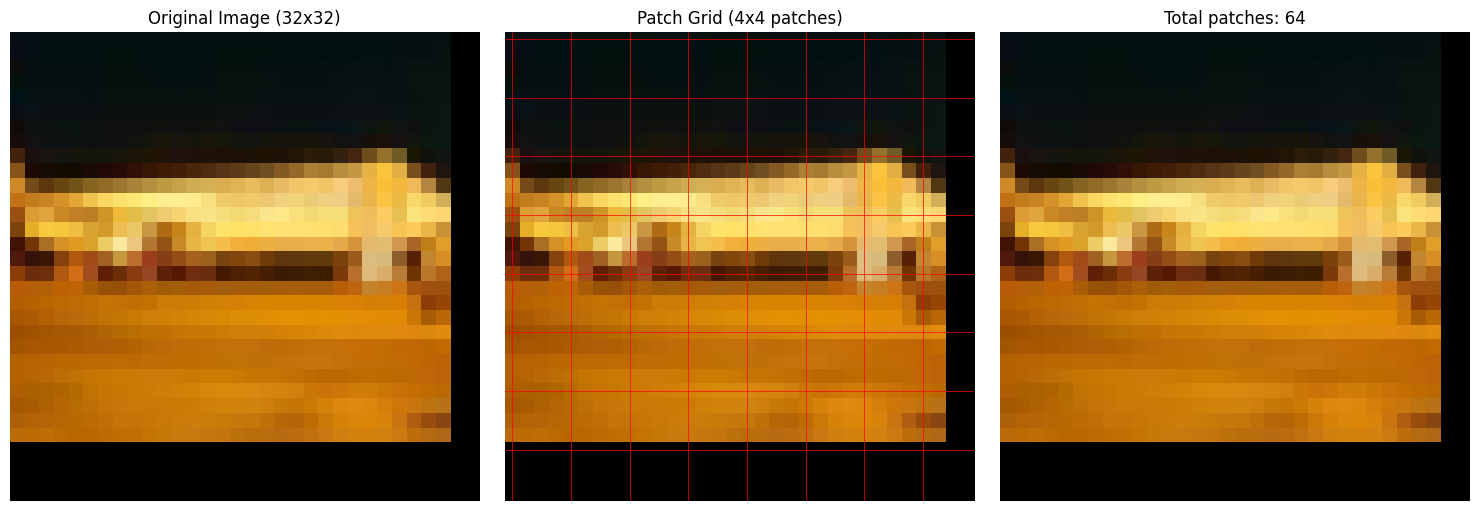

In [15]:
def visualize_patches(image, patch_size=4):
    img = image * 0.5 + 0.5
    img = img.numpy().transpose(1, 2, 0)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original Image (32x32)')
    axes[0].axis('off')
    axes[1].imshow(img)
    for i in range(0, 32, patch_size):
        axes[1].axhline(i, color='red', linewidth=0.5)
        axes[1].axvline(i, color='red', linewidth=0.5)
    axes[1].set_title(f'Patch Grid ({patch_size}x{patch_size} patches)')
    axes[1].axis('off')
    num_patches_per_side = 32 // patch_size
    patch_grid = np.zeros((32, 32, 3))

    for i in range(num_patches_per_side):
        for j in range(num_patches_per_side):
            patch = img[i*patch_size:(i+1)*patch_size,
                       j*patch_size:(j+1)*patch_size]
            patch_grid[i*patch_size:(i+1)*patch_size,
                      j*patch_size:(j+1)*patch_size] = patch

    axes[2].imshow(patch_grid)
    axes[2].set_title(f'Total patches: {num_patches_per_side**2}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

img, label = train_dataset[np.random.randint(len(train_dataset))]
print(f"Visualizing patches for: {classes[label]}")
visualize_patches(img, patch_size=4)

In [22]:
import torch.optim as optim
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MLPMixer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=256,
    num_blocks=8,
    token_mix_hidden=256,
    channel_mix_hidden=512
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
print(f"\nModel has {sum(p.numel() for p in model.parameters()):,} parameters")

Using device: cuda

Model has 2,408,202 parameters


In [23]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc='Training')

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.3f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [24]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                num_epochs=50, device='cuda'):
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        scheduler.step()
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_mlp_mixer.pth')
            print(f"✓ New best model saved! (Test Acc: {best_acc:.2f}%)")

    return train_losses, train_accs, test_losses, test_accs

In [25]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(test_loader, desc='Evaluating')

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({
                'loss': f'{running_loss/len(pbar):.3f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [26]:
print("Starting Training")
train_losses, train_accs, test_losses, test_accs = train_model(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    num_epochs=75,
    device=device
)

Starting Training

Epoch 1/75


Evaluating: 100%|██████████| 79/79 [00:03<00:00, 23.26it/s, loss=1.617, acc=40.26%]



Train Loss: 1.8600 | Train Acc: 31.23%
Test Loss: 1.6174 | Test Acc: 40.26%
Learning Rate: 0.001000
✓ New best model saved! (Test Acc: 40.26%)

Epoch 2/75


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 27.70it/s, loss=1.436, acc=47.71%]



Train Loss: 1.5791 | Train Acc: 42.57%
Test Loss: 1.4358 | Test Acc: 47.71%
Learning Rate: 0.001000
✓ New best model saved! (Test Acc: 47.71%)

Epoch 3/75


...


Train Loss: 0.1192 | Train Acc: 95.68%
Test Loss: 1.0790 | Test Acc: 75.99%
Learning Rate: 0.000706

Epoch 74/75


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 26.83it/s, loss=1.102, acc=75.67%]



Train Loss: 0.1104 | Train Acc: 96.14%
Test Loss: 1.1020 | Test Acc: 75.67%
Learning Rate: 0.000699

Epoch 75/75


Evaluating: 100%|██████████| 79/79 [00:03<00:00, 20.83it/s, loss=1.108, acc=76.27%]


Train Loss: 0.1060 | Train Acc: 96.29%
Test Loss: 1.1077 | Test Acc: 76.27%
Learning Rate: 0.000691


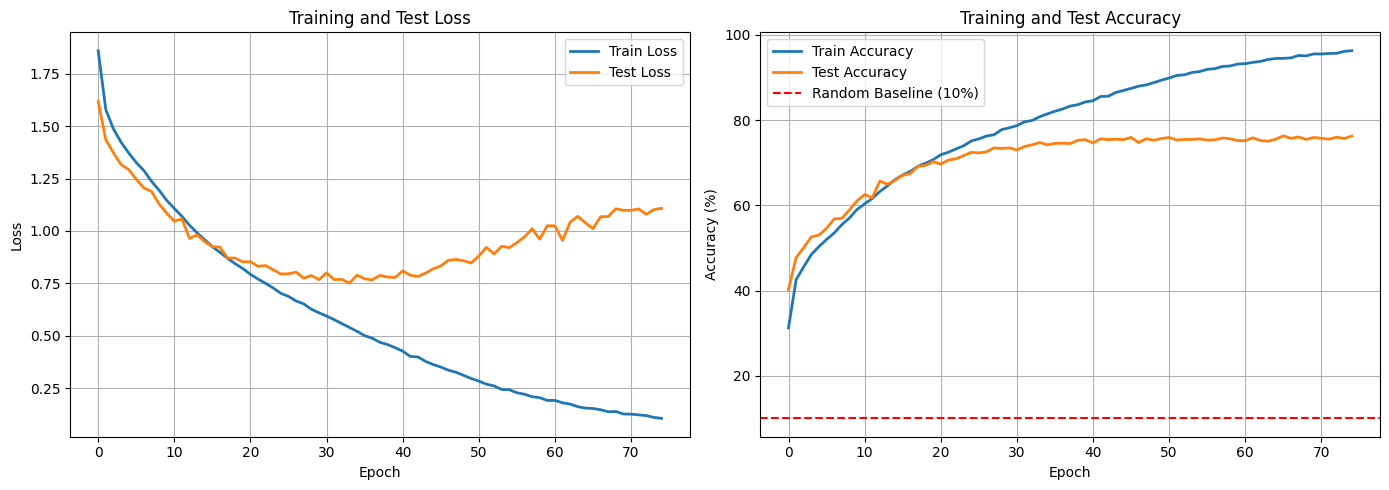


Final Results:
Best Test Accuracy: 76.31%
Final Train Accuracy: 96.29%
Final Test Accuracy: 76.27%


In [28]:
def plot_training_history(train_losses, train_accs, test_losses, test_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label='Train Loss', linewidth=2)
    ax1.plot(test_losses, label='Test Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Test Loss')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
    ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
    ax2.axhline(y=10, color='r', linestyle='--', label='Random Baseline (10%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Test Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Results:")
    print(f"Best Test Accuracy: {max(test_accs):.2f}%")
    print(f"Final Train Accuracy: {train_accs[-1]:.2f}%")
    print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")

plot_training_history(train_losses, train_accs, test_losses, test_accs)

Evaluating: 100%|██████████| 79/79 [00:03<00:00, 24.28it/s]


              precision    recall  f1-score   support

       plane     0.7981    0.8300    0.8137      1000
         car     0.8718    0.8570    0.8643      1000
        bird     0.6704    0.7160    0.6925      1000
         cat     0.5968    0.5240    0.5580      1000
        deer     0.6951    0.7570    0.7247      1000
         dog     0.6205    0.7030    0.6592      1000
        frog     0.8510    0.7540    0.7996      1000
       horse     0.8365    0.7930    0.8142      1000
        ship     0.8906    0.8550    0.8724      1000
       truck     0.8296    0.8420    0.8357      1000

    accuracy                         0.7631     10000
   macro avg     0.7660    0.7631    0.7634     10000
weighted avg     0.7660    0.7631    0.7634     10000

plane     :  83.00% (830/1000)
car       :  85.70% (857/1000)
bird      :  71.60% (716/1000)
cat       :  52.40% (524/1000)
deer      :  75.70% (757/1000)
dog       :  70.30% (703/1000)
frog      :  75.40% (754/1000)
horse     :  79.30% (793

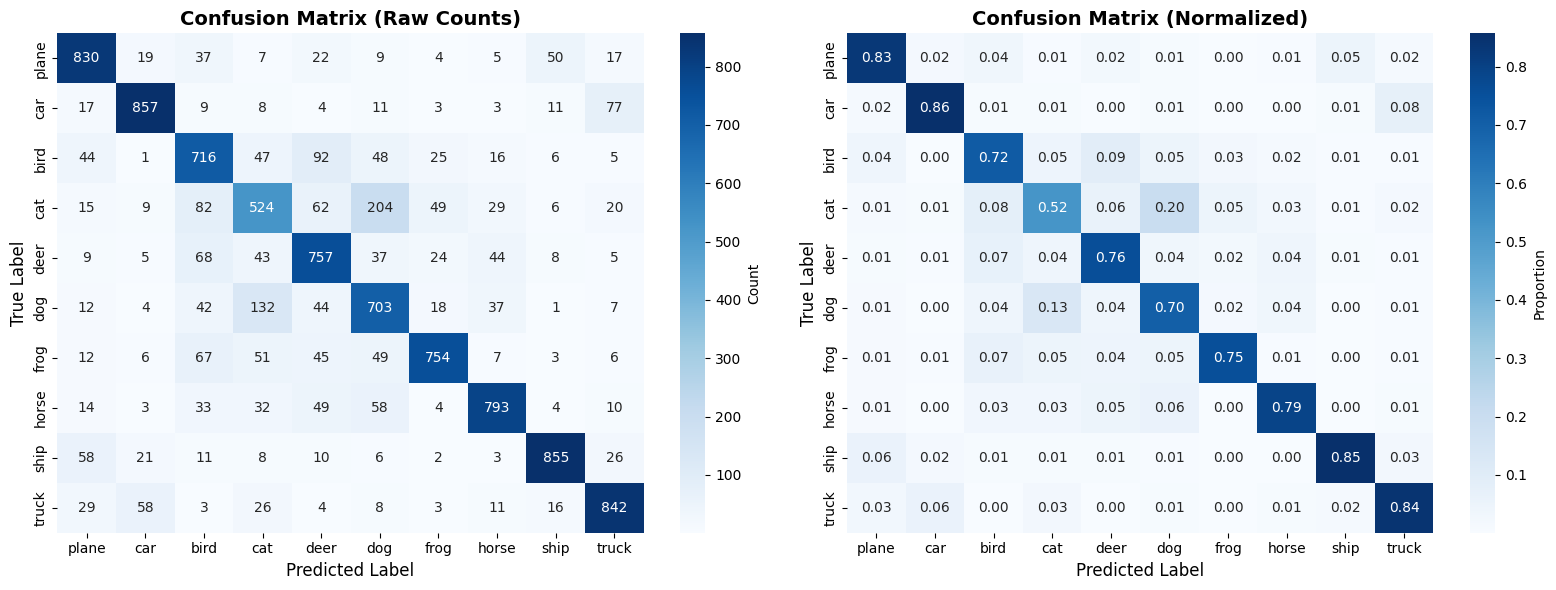



Count    True Class   Predicted As


204      cat          dog         
132      dog          cat         
92       bird         deer        
82       cat          bird        
77       car          truck       
68       deer         bird        
67       frog         bird        
62       cat          deer        
58       truck        car         
58       ship         plane       


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load('best_mlp_mixer.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

class_correct = np.zeros(10)
class_total = np.zeros(10)
for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

for i, class_name in enumerate(classes):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f"{class_name:10s}: {accuracy:6.2f}% ({int(class_correct[i])}/{int(class_total[i])})")
overall_acc = 100 * class_correct.sum() / class_total.sum()
print(f"{'Overall':10s}: {overall_acc:6.2f}%")
best_idx = np.argmax(class_correct / class_total)
worst_idx = np.argmin(class_correct / class_total)
print("\n")
print(f"\n✓ Best:  {classes[best_idx]} ({100*class_correct[best_idx]/class_total[best_idx]:.2f}%)")
print(f"✗ Worst: {classes[worst_idx]} ({100*class_correct[worst_idx]/class_total[worst_idx]:.2f}%)")
print("\n")
cm = confusion_matrix(all_labels, all_preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax1,
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax2,
            cbar_kws={'label': 'Proportion'})
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n")
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j:
            mistakes.append((cm[i, j], classes[i], classes[j]))
mistakes.sort(reverse=True)
print(f"{'Count':<8} {'True Class':<12} {'Predicted As':<12}")
print("\n")
for count, true_class, pred_class in mistakes[:10]:
    print(f"{int(count):<8} {true_class:<12} {pred_class:<12}")

